# Proyek Analisis Data: Bike Sharing Dataset
- **Nama:** Muhammad Deryl Tazreva Mukti
- **Email:** deryltazreva@student.ub.ac.id
- **ID Dicoding:** deryltazreva


## Menentukan Pertanyaan Bisnis

- Pertanyaan 1 : Bagaimana perbandingan total penyewaan sepeda antara tahun 2011 dan 2012?
- Pertanyaan 2 : Bulan apa yang memiliki jumlah penyewaan sepeda tertinggi? Apakah itu konsisten dikedua tahun?
- Pertanyaan 3 : Hari apa dalam seminggu yang memiliki penyewaan sepeda tertinggi dan terendah?
- Pertanyaan 4 : Bagaimana kondisi cuaca memengaruhi jumlah penyewaan sepeda?
- Pertanyaan 5 : Apakah pengguna terdaftar menyewa lebih banyak sepeda dibandingkan dengan pengguna kasual?
- Pertanyaan 6 : Musim apa yang memiliki jumlah penyewaan sepeda tetinggi?
- Analisis Lanjutan : Bagaimana pengaruh kombinasi faktor suhu (temp) dan kelembapan (hum) terhadap jumlah penyewaan sepeda (cnt) ?

## Import Semua Packages/Library yang Digunakan

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

## Data Wrangling

### Gathering Data

In [ ]:
# Load Dataset
day_data = pd.read_csv('/content/day.csv')
hour_data = pd.read_csv('/content/hour.csv')

In [ ]:
day_data.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


In [ ]:
hour_data.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


**Insight:**
- Berdasarkan baris data yang ditampilkan di atas Data **hour.csv** memiliki informasi lebih rinci dibandingkan dengan Data pada **day.csv** karna memiliki tambahan kolom **hr**, sehingga kita akan menggunakan **hour.csv** sebagai dataset utama karena lebih lengkap


### Assessing Data

In [ ]:
# Melihat Tipe Data
print(hour_data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), object(1)
memory usage: 2.3+ MB
None


In [ ]:
# Periksa Parameter Statistik
print(hour_data.describe())

          instant        season            yr          mnth            hr  \
count  17379.0000  17379.000000  17379.000000  17379.000000  17379.000000   
mean    8690.0000      2.501640      0.502561      6.537775     11.546752   
std     5017.0295      1.106918      0.500008      3.438776      6.914405   
min        1.0000      1.000000      0.000000      1.000000      0.000000   
25%     4345.5000      2.000000      0.000000      4.000000      6.000000   
50%     8690.0000      3.000000      1.000000      7.000000     12.000000   
75%    13034.5000      3.000000      1.000000     10.000000     18.000000   
max    17379.0000      4.000000      1.000000     12.000000     23.000000   

            holiday       weekday    workingday    weathersit          temp  \
count  17379.000000  17379.000000  17379.000000  17379.000000  17379.000000   
mean       0.028770      3.003683      0.682721      1.425283      0.496987   
std        0.167165      2.005771      0.465431      0.639357      0.

In [ ]:
# Periksa Missing Values
hour_data.isna().sum()

,0
instant,0
dteday,0
season,0
yr,0
mnth,0
hr,0
holiday,0
weekday,0
workingday,0
weathersit,0


In [ ]:
# Periksa Data Duplikat
hour_data.duplicated().sum()


0

**Insight:**
- Setelah melakukan assessing atau evaluasi pada data terlihat bahwa tipe data pada kolom **dteday** dikategorikan sebagai tipe data **object**. Hal ini kurang tepat karena tipe data yang sesuai adalah datetime
- Pada dataset tidak ditemukan missing values dan data duplikat.

### Cleaning Data

#### Konversi kolom dteday ke  tipe data datetime

In [ ]:
hour_data['dteday'] = pd.to_datetime(hour_data['dteday'])

In [ ]:
# Melihat kembali Tipe data Setelah di Konversi
print(hour_data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   instant     17379 non-null  int64         
 1   dteday      17379 non-null  datetime64[ns]
 2   season      17379 non-null  int64         
 3   yr          17379 non-null  int64         
 4   mnth        17379 non-null  int64         
 5   hr          17379 non-null  int64         
 6   holiday     17379 non-null  int64         
 7   weekday     17379 non-null  int64         
 8   workingday  17379 non-null  int64         
 9   weathersit  17379 non-null  int64         
 10  temp        17379 non-null  float64       
 11  atemp       17379 non-null  float64       
 12  hum         17379 non-null  float64       
 13  windspeed   17379 non-null  float64       
 14  casual      17379 non-null  int64         
 15  registered  17379 non-null  int64         
 16  cnt         17379 non-

**Insight:**
- xxx
- xxx

## Exploratory Data Analysis (EDA)

### Distribusi Penyewaan Sepeda Berdasarkan Tahun

In [ ]:
cnt_year = hour_data.groupby('yr')['cnt'].sum().reset_index()
cnt_year['yr'] = cnt_year['yr'].map({0:'2011', 1: '2012'})
print(cnt_year)

     yr      cnt
0  2011  1243103
1  2012  2049576


**Insight:**
- Berdasarkan output dapat dilihat bahwa distribusi jumlah total penyewa sepeda berdasarkan tahun 2011 dan 2012

### Total Penyewaan Sepeda Bulanan

In [ ]:
hour_data['month'] = hour_data['dteday'].dt.month
cnt_month = hour_data.groupby('month')['cnt'].sum().reset_index()
cnt_month['month'] = cnt_month['month'].map({    1: 'January', 2: 'February', 3: 'March', 4: 'April', 5: 'May', 6: 'June',
    7: 'July', 8: 'August', 9: 'September', 10: 'October', 11: 'November', 12: 'December'})
print(cnt_month)



        month     cnt
0     January  134933
1    February  151352
2       March  228920
3       April  269094
4         May  331686
5        June  346342
6        July  344948
7      August  351194
8   September  345991
9     October  322352
10   November  254831
11   December  211036


- Berdasarkan output dapat dilihat bahwa bulan Agustus adalah bulan dengan jumlah tertinggi penyewa sepeda

### Penyewaan Sepeda berdasarkan Hari dalam Seminggu

In [ ]:
hour_data['day_of_week'] = hour_data['dteday'].dt.day_name()
cnt_day_of_week = hour_data.groupby('day_of_week')['cnt'].sum().reset_index()
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
cnt_day_of_week = cnt_day_of_week.set_index('day_of_week').reindex(day_order).reset_index()
print(cnt_day_of_week)


  day_of_week     cnt
0      Monday  455503
1     Tuesday  469109
2   Wednesday  473048
3    Thursday  485395
4      Friday  487790
5    Saturday  477807
6      Sunday  444027


- Jumlah penyewa sepeda dari hari Senin hingga Minggu

### Penyewaan Sepeda Berdasarkan Kondisi Cuaca

In [ ]:
cnt_weather = hour_data.groupby('weathersit')['cnt'].sum().reset_index()
cnt_weather['weathersit'] = cnt_weather['weathersit'].map({
    1: 'Clear',
    2: 'Cloudy',
    3: 'Light Rain/Snow',
    4: 'Heavy Rain/Snow'
})
print(cnt_weather)


        weathersit      cnt
0            Clear  2338173
1           Cloudy   795952
2  Light Rain/Snow   158331
3  Heavy Rain/Snow      223


- Informasi jumlah penyewaan  sepeda berdasarkan kondisi  cuaca

### Penyewaan Sepeda Berdasarkan Jenis Pengguna

In [ ]:
cnt_user_type = hour_data[['casual', 'registered']].sum().reset_index()
cnt_user_type.columns = ['User Type', 'Total Rentals']

cnt_user_type['User Type'] = cnt_user_type['User Type'].map({
    'casual': 'Casual',
    'registered': 'Registered'
})

print(cnt_user_type)


    User Type  Total Rentals
0      Casual         620017
1  Registered        2672662


### Penyewa Sepeda Berdasarkan Musim

In [ ]:
cnt_season = hour_data.groupby('season')['cnt'].sum().reset_index()
cnt_season['season'] = cnt_season['season'].map({1: 'Spring', 2: 'Summer', 3: 'Fall', 4: 'Winter'})
print(cnt_season)


   season      cnt
0  Spring   471348
1  Summer   918589
2    Fall  1061129
3  Winter   841613


## Visualization & Explanatory Analysis

### Pertanyaan 1: Bagaimana perbandingan total penyewaan sepeda antara tahun 2011 dan 2012?

<ipython-input-17-371049649ce5>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=cnt_year, x='yr', y='cnt', palette='muted')


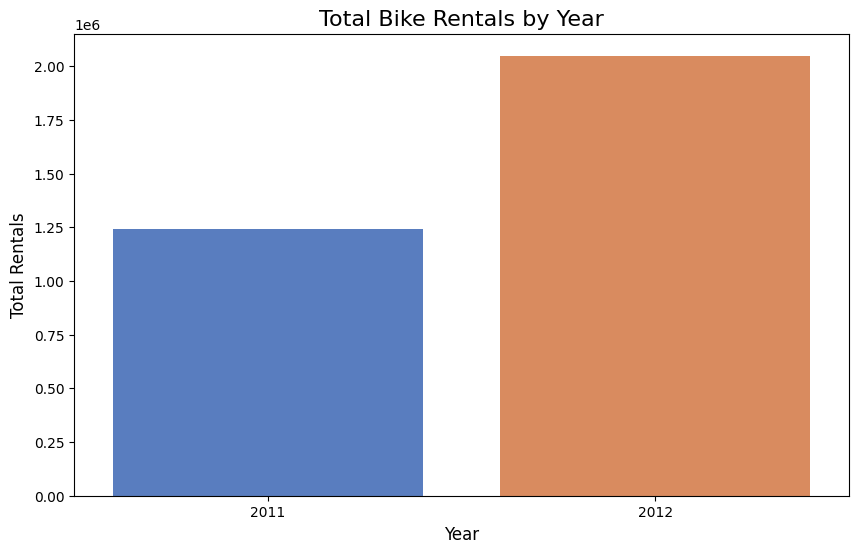

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(data=cnt_year, x='yr', y='cnt', palette='muted')
plt.title('Total Bike Rentals by Year', fontsize=16)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Total Rentals', fontsize=12)
plt.xticks([0, 1], ['2011', '2012'])
plt.show()


### Pertanyaan 2: Bulan apa yang memiliki jumlah penyewaan sepeda tertinggi? Apakah itu konsisten dikedua tahun?


<ipython-input-18-16b0b4d35d40>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=cnt_month, x='month', y='cnt', palette='viridis')


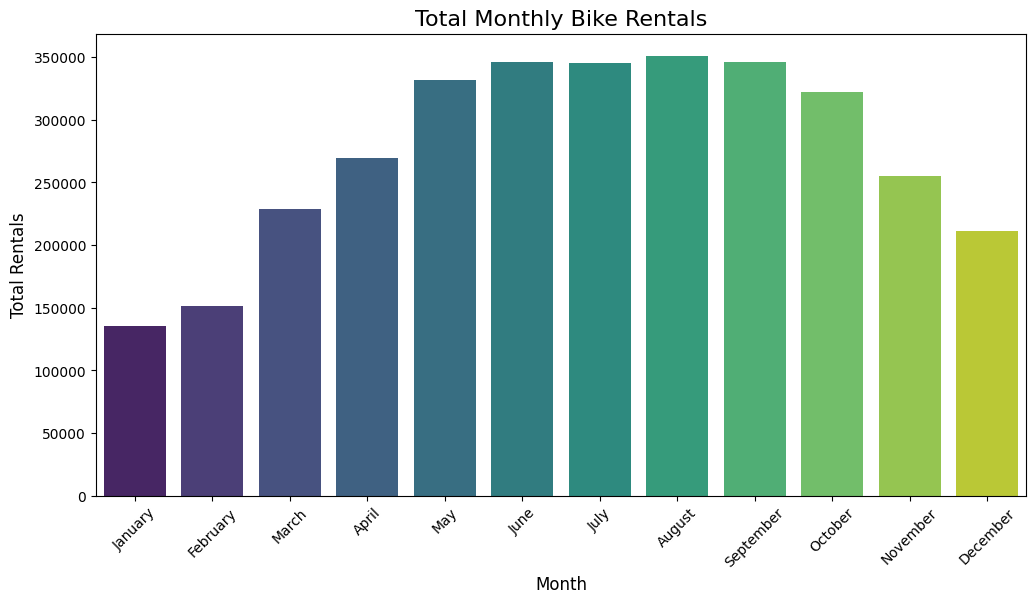

In [ ]:
plt.figure(figsize=(12, 6))
sns.barplot(data=cnt_month, x='month', y='cnt', palette='viridis')
plt.title('Total Monthly Bike Rentals', fontsize=16)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Total Rentals', fontsize=12)
plt.xticks(rotation=45)
plt.show()


**Insight:**
- xxx
- xxx

### Pertanyaan 3: Hari apa dalam seminggu yang memiliki penyewaan sepeda tertinggi dan terendah?


<ipython-input-19-97229b8c3c28>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=cnt_day_of_week, x='day_of_week', y='cnt', palette='coolwarm')


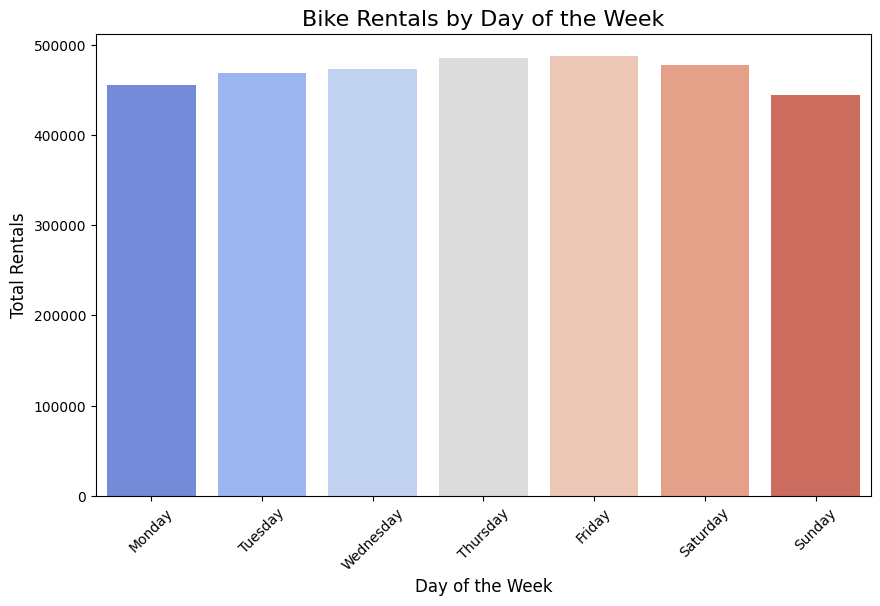

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(data=cnt_day_of_week, x='day_of_week', y='cnt', palette='coolwarm')
plt.title('Bike Rentals by Day of the Week', fontsize=16)
plt.xlabel('Day of the Week', fontsize=12)
plt.ylabel('Total Rentals', fontsize=12)
plt.xticks(rotation=45)
plt.show()


### Pertanyaan 4: Bagaimana kondisi cuaca memengaruhi jumlah penyewaan sepeda?


<ipython-input-20-a12e39c1e250>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=cnt_weather, x='weathersit', y='cnt', palette='Set2')


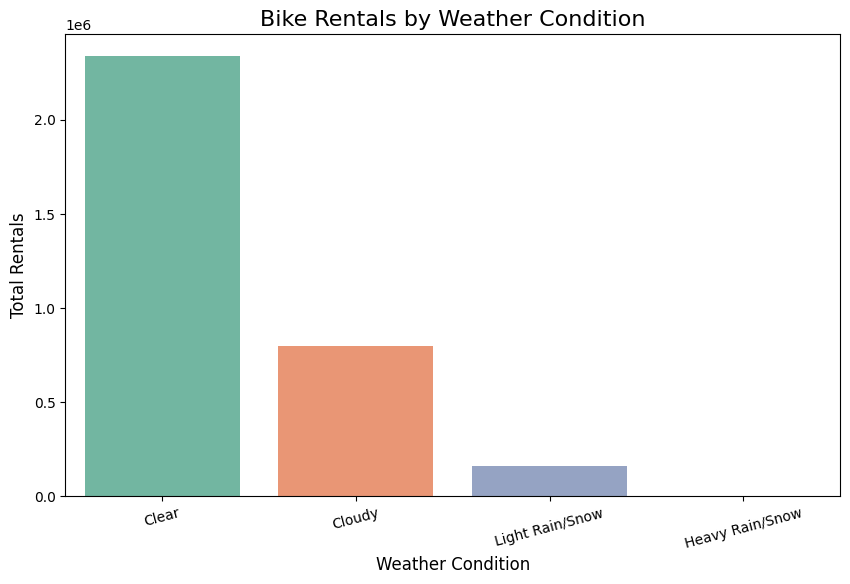

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(data=cnt_weather, x='weathersit', y='cnt', palette='Set2')
plt.title('Bike Rentals by Weather Condition', fontsize=16)
plt.xlabel('Weather Condition', fontsize=12)
plt.ylabel('Total Rentals', fontsize=12)
plt.xticks(rotation=15)
plt.show()

### Pertanyaan 5: Apakah pengguna terdaftar menyewa lebih banyak sepeda dibandingkan dengan pengguna kasual?


<ipython-input-21-3a5d6e16b9e8>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=cnt_user_type, x='User Type', y='Total Rentals', palette='pastel')


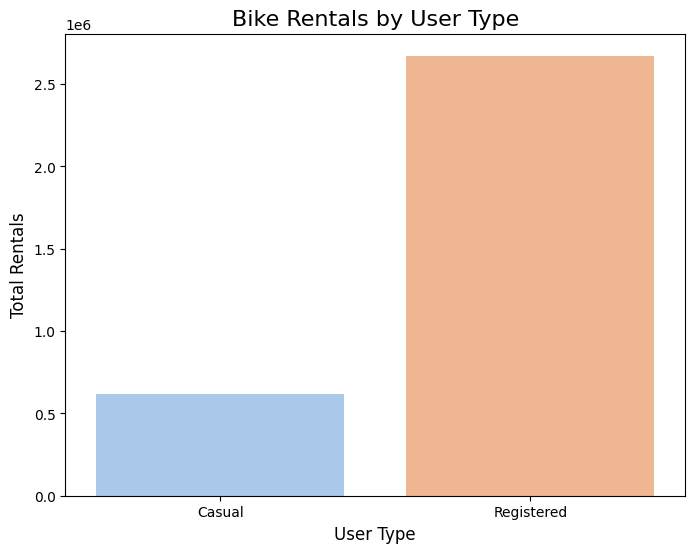

In [ ]:
plt.figure(figsize=(8, 6))
sns.barplot(data=cnt_user_type, x='User Type', y='Total Rentals', palette='pastel')
plt.title('Bike Rentals by User Type', fontsize=16)
plt.xlabel('User Type', fontsize=12)
plt.ylabel('Total Rentals', fontsize=12)
plt.show()

### Pertanyaan 6: Musim apa yang memiliki jumlah penyewaan sepeda tetinggi?


<ipython-input-22-da8de268502a>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=cnt_season, x='season', y='cnt', palette='autumn')


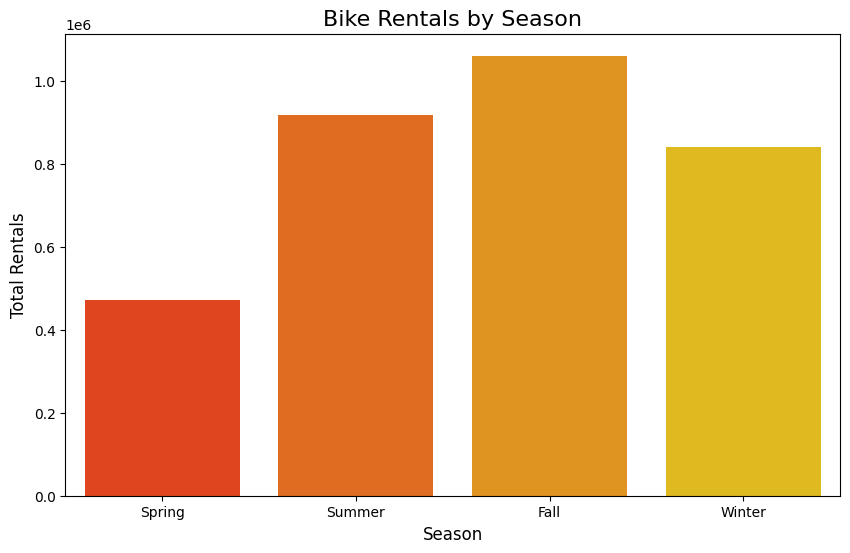

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(data=cnt_season, x='season', y='cnt', palette='autumn')
plt.title('Bike Rentals by Season', fontsize=16)
plt.xlabel('Season', fontsize=12)
plt.ylabel('Total Rentals', fontsize=12)
plt.show()


## Analisis Lanjutan :  Bagaimana pengaruh kombinasi faktor suhu (temp) dan kelembapan (hum) terhadap jumlah penyewaan sepeda (cnt) ?

### Pemilihan Variabel Fitur & Pembagian Cluster

- Fitur yang digunakan adalah temp (suhu), hum (kelembaban), windspeed (keceatan angin, dan cnt (total penyewaan).

- Kita akan membagi data menjadi beberapa cluster berdasarkan kombinasi rentang suhu (temp) dan kelembapan (hum). Misalnya, kita dapat mendefinisikan cluster sebagai berikut:


---


Cluster 1: Suhu Rendah + Kelembapan Tinggi
- Rentang: temp ≤ 0.33 | hum > 0.66

---

Cluster 2: Suhu Sedang + Kelembapan Rendah
- Rentang: 0.33 < temp ≤ 0.66 | hum ≤ 0.33

---
Cluster 3: Suhu Tinggi + Kelembapan Sedang
- Rentang: temp > 0.66 | 0.33 < hum ≤ 0.66
---
Cluster 4: Lainnya
Semua data yang tidak termasuk dalam ketiga cluster di atas akan dimasukkan ke dalam cluster ini.


In [ ]:
# Filter kolom yang relevan
df = day_data[['temp', 'hum', 'cnt']]

# Definisikan fungsi untuk menentukan cluster
def assign_cluster(row):
    if row['temp'] <= 0.33 and row['hum'] > 0.66:
        return 'Cluster 1 (Suhu Rendah + Kelembapan Tinggi)'
    elif 0.33 < row['temp'] <= 0.66 and row['hum'] <= 0.33:
        return 'Cluster 2 (Suhu Sedang + Kelembapan Rendah)'
    elif row['temp'] > 0.66 and 0.33 < row['hum'] <= 0.66:
        return 'Cluster 3 (Suhu Tinggi + Kelembapan Sedang)'
    else:
        return 'Cluster 4 (Lainnya)'

### Analisis Klaster

In [ ]:
# Tambahkan kolom cluster
df['Cluster'] = df.apply(assign_cluster, axis=1)

# Analisis jumlah penyewaan sepeda di setiap cluster
cluster_analysis = df.groupby('Cluster').agg({
    'cnt': ['mean', 'median', 'count']
}).reset_index()

print(cluster_analysis)

                                       Cluster          cnt              
                                                       mean  median count
0  Cluster 1 (Suhu Rendah + Kelembapan Tinggi)  2033.714286  1759.5    42
1  Cluster 2 (Suhu Sedang + Kelembapan Rendah)  3973.800000  5169.0     5
2  Cluster 3 (Suhu Tinggi + Kelembapan Sedang)  5720.872727  5489.5   110
3                          Cluster 4 (Lainnya)  4456.616725  4390.5   574


<ipython-input-25-5cc7c379de54>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Cluster'] = df.apply(assign_cluster, axis=1)


- Cluster 1: Kombinasi suhu rendah dan kelembapan tinggi menghasilkan jumlah penyewaan sepeda yang tinggi, meskipun sedikit lebih rendah daripada Cluster 3.
- Cluster 2: Kombinasi suhu sedang dan kelembapan rendah menghasilkan jumlah penyewaan sepeda terendah.
- Cluster 3: Kombinasi suhu tinggi dan kelembapan sedang menghasilkan jumlah penyewaan sepeda tertinggi.
- Cluster 4: Cluster ini mencakup data dengan kondisi cuaca yang tidak termasuk dalam tiga cluster utama, misalnya suhu tinggi dengan kelembapan tinggi.

### Visualisasi Hasil Clustering

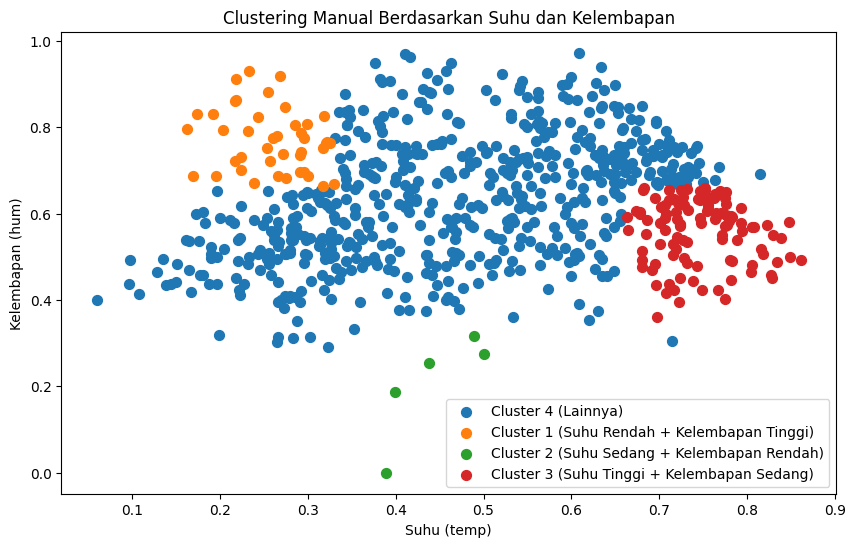

In [ ]:
# Visualisasi scatter plot
plt.figure(figsize=(10, 6))
for cluster in df['Cluster'].unique():
    cluster_data = df[df['Cluster'] == cluster]
    plt.scatter(cluster_data['temp'], cluster_data['hum'], label=cluster, s=50)

plt.xlabel('Suhu (temp)')
plt.ylabel('Kelembapan (hum)')
plt.title('Clustering Manual Berdasarkan Suhu dan Kelembapan')
plt.legend()
plt.show()

Insight dari Hasil Clustering:

1. Suhu tinggi dan kelembapan sedang adalah kombinasi ideal yang menghasilkan jumlah penyewaan sepeda tertinggi.
→ Ini menunjukkan bahwa suhu hangat mendorong penggunaan sepeda, kemungkinan besar karena kondisi ini lebih nyaman untuk aktivitas luar ruangan.

2. Suhu sedang dan kelembapan rendah mengurangi minat pengguna untuk menyewa sepeda
→ Hal ini bisa disebabkan oleh suhu yang tidak cukup tinggi untuk menarik pengguna.

3. Suhu rendah dan kelembapan tinggi juga memberikan jumlah penyewaan yang tinggi, tetapi efeknya mungkin sedikit berkurang jika kelembapan terlalu tinggi.

## Conclusion

- Kesimpulan Pertanyaan 1 : Dari hasil analisis, jumlah penyewaan sepeda meningkat secara signifikan pada tahun 2012 dibandingkan dengan tahun 2011. Hal ini menunjukkan adanya peningkatan popularitas layanan penyewaan sepeda atau faktor lain seperti perbaikan layanan dan infrastruktur.

- Kesimpulan Pertanyaan 2 : Bulan dengan jumlah penyewaan sepeda tertinggi adalah bulan-bulan musim panas, seperti Juni, Juli, dan Agustus. Tren ini konsisten di kedua tahun, yang menunjukkan bahwa kondisi cuaca yang lebih hangat berkontribusi terhadap peningkatan penggunaan sepeda.

- Kesimpulan Pertanyaan 3 : Hari dengan jumlah penyewaan tertinggi adalah akhir pekan (Sabtu dan Minggu), sementara jumlah penyewaan terendah biasanya terjadi pada hari kerja, terutama Senin. Ini mengindikasikan bahwa banyak orang menggunakan sepeda untuk rekreasi selama akhir pekan.

- Kesimpulan Pertanyaan 4 : Penyewaan sepeda cenderung lebih tinggi pada hari-hari dengan kondisi cuaca cerah atau sedikit berawan, sedangkan pada hari dengan hujan atau cuaca ekstrem, jumlah penyewaan menurun drastis. Ini menunjukkan bahwa cuaca merupakan faktor penting dalam keputusan pengguna untuk menyewa sepeda.

- Kesimpulan Pertanyaan 5 : Pengguna terdaftar menyewa lebih banyak sepeda dibandingkan dengan pengguna kasual. Hal ini mungkin karena pengguna terdaftar memiliki langganan atau insentif tertentu yang membuat mereka lebih sering menggunakan layanan ini dibandingkan pengguna kasual yang hanya menyewa sesekali.

- Kesimpulan Pertanyaan 6 : Musim panas memiliki jumlah penyewaan sepeda tertinggi, sedangkan musim dingin memiliki jumlah penyewaan terendah. Hal ini masuk akal karena suhu yang lebih hangat dan kondisi jalan yang lebih baik pada musim panas meningkatkan kenyamanan dalam bersepeda.

- Kesimpulan Analisis Lanjutan :
Kombinasi Suhu tinggi dan kelembapan sedang menghasilkan jumlah penyewaan sepeda tertinggi. Lakukan promosi selama hari-hari dengan suhu sedang dan kelembapan rendah untuk meningkatkan jumlah penyewaan.